# Ad exposure and conversion: exploratory analysis

## What this notebook checks

This notebook looks at users in the `ad` group and asks a simple question: **were users who saw more ads also more likely to convert?**

This is an exploratory analysis, not proof that additional ads caused the higher conversion rate. The actual number of exposures may have depended on user activity, targeting, time spent in the campaign, or delivery rules. Because of that, the results should be treated as an association and used mainly to generate follow-up questions.

The main A/B-test result still comes from comparing everyone assigned to `ad` with everyone assigned to `psa`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.stats import pointbiserialr
from statsmodels.stats.proportion import proportion_confint

ALPHA = 0.05


def find_project_root() -> Path:
    """Find the repository root from the current working directory."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data" / "raw" / "marketing_AB.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate data/raw/marketing_AB.csv. "
        "Run the notebook from inside the project repository."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "marketing_AB.csv"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

required_columns = ["test group", "converted", "total ads"]
df = pd.read_csv(DATA_PATH, usecols=required_columns)
df["total ads"] = pd.to_numeric(df["total ads"], errors="coerce")

# Normalize the conversion column if it was imported as text or integers.
if not pd.api.types.is_bool_dtype(df["converted"]):
    normalized = df["converted"].astype(str).str.strip().str.lower()
    mapping = {"true": True, "false": False, "1": True, "0": False}
    df["converted"] = normalized.map(mapping)

if df[required_columns].isna().any().any():
    missing = df[required_columns].isna().sum()
    raise ValueError(f"Missing or unsupported values found:\n{missing}")

if not df["test group"].isin(["ad", "psa"]).all():
    raise ValueError("Unexpected values found in 'test group'.")

if (df["total ads"] < 1).any():
    raise ValueError("'total ads' must contain positive values.")

ad_group = df.loc[df["test group"].eq("ad")].copy()

print(f"Ad-group users: {len(ad_group):,}")
print(
    "Recorded exposures: "
    f"median={ad_group['total ads'].median():.0f}, "
    f"95th percentile={ad_group['total ads'].quantile(0.95):.0f}, "
    f"maximum={ad_group['total ads'].max():,}"
)

Ad-group users: 564,577
Recorded exposures: median=13, 95th percentile=87, maximum=2,065


## 1. Conversion across exposure groups

Users are divided into ten groups based on their recorded number of ad exposures. Quantile-based groups are used so that each group contains roughly a similar number of users.

The group sizes are not exactly equal because `total ads` contains repeated integer values. Users with the same exposure count cannot always be split cleanly between two groups.

In [2]:
ad_group["exposure_bucket"] = pd.qcut(
    ad_group["total ads"],
    q=10,
    duplicates="drop",
)

association = (
    ad_group.groupby("exposure_bucket", observed=True)
    .agg(
        users=("converted", "size"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        median_exposures=("total ads", "median"),
    )
    .reset_index()
)

intervals = association.apply(
    lambda row: proportion_confint(
        count=int(row["conversions"]),
        nobs=int(row["users"]),
        alpha=ALPHA,
        method="wilson",
    ),
    axis=1,
)

association["ci_low"] = [interval[0] for interval in intervals]
association["ci_high"] = [interval[1] for interval in intervals]

association

,exposure_bucket,users,conversions,conversion_rate,median_exposures,ci_low,ci_high
0,"(0.999, 2.0]",92209,177,0.001920,1.0,0.001657,0.002224
1,"(2.0, 3.0]",27328,77,0.002818,3.0,0.002255,0.003520
2,"(3.0, 5.0]",50425,173,0.003431,5.0,0.002957,0.003980
3,"(5.0, 8.0]",56051,236,0.004210,7.0,0.003707,0.004782
4,"(8.0, 13.0]",60882,416,0.006833,11.0,0.006209,0.007519
5,"(13.0, 17.0]",56368,439,0.007788,15.0,0.007095,0.008548
6,"(17.0, 24.0]",61873,801,0.012946,21.0,0.012085,0.013867
7,"(24.0, 33.0]",47226,1074,0.022742,28.0,0.021435,0.024126
8,"(33.0, 56.0]",55801,2870,0.051433,42.0,0.049631,0.053297
9,"(56.0, 2065.0]",56414,8160,0.144645,88.0,0.141767,0.147572


## 2. Overall strength of the association

The point-biserial correlation summarizes the relationship between a numeric variable (`total ads`) and a binary outcome (`converted`).

The coefficient is useful as a compact summary, but it should not be treated as the main result. `total ads` is highly skewed, the relationship may not be linear, and the sample is so large that even weak associations can produce extremely small p-values. The bucketed conversion rates are therefore easier to interpret.

In [3]:
correlation, _ = pointbiserialr(
    ad_group["converted"].astype(int),
    ad_group["total ads"],
)

print(f"Point-biserial correlation: r = {correlation:.3f}")

Point-biserial correlation: r = 0.219


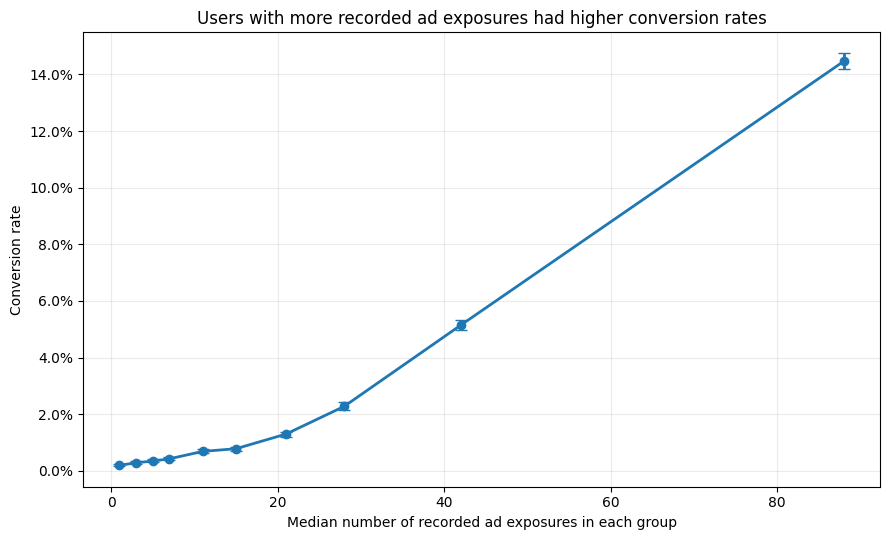

Saved: visuals/exposure_conversion_association.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

x = association["median_exposures"].to_numpy()
errors = np.vstack(
    [
        association["conversion_rate"] - association["ci_low"],
        association["ci_high"] - association["conversion_rate"],
    ]
)

ax.errorbar(
    x,
    association["conversion_rate"],
    yerr=errors,
    marker="o",
    capsize=4,
    linewidth=2,
)

ax.set_xlabel("Median number of recorded ad exposures in each group")
ax.set_ylabel("Conversion rate")
ax.set_title(
    "Users with more recorded ad exposures had higher conversion rates"
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="both", alpha=0.25)

fig.tight_layout()

output_path = VISUALS_DIR / "exposure_conversion_association.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {output_path.relative_to(PROJECT_ROOT)}")

## What the results mean

Users with more recorded ad exposures had much higher conversion rates. The correlation is also positive, so both summaries point in the same direction.

This still does not show that displaying more ads causes more conversions. Other explanations are possible:

- more active users may have had more opportunities both to see ads and to convert;
- the targeting system may have shown more ads to users who already looked more likely to convert;
- users may have remained in the campaign for different lengths of time;
- campaign rules may have changed ad delivery after a conversion;
- other user or session characteristics may have affected both exposure and conversion.

To estimate the causal effect of ad frequency, users would ideally be randomly assigned to different frequency limits. Without that design, timestamps, and richer user-level information, this should remain an exploratory supporting analysis rather than a basis for the rollout decision.